# spatialdetection quickstart

Interactive tour of the library. Every clustering/autocorrelation function
takes a plain `pandas.DataFrame` with `lon`/`lat` columns directly — no
need to build a `GeoDataFrame` yourself first.

Run all cells (Kernel > Restart & Run All), or open this in VS Code with the
Jupyter extension and pick the `spatialdetection` (`.venv`) kernel.

In [1]:
import json
import warnings

import numpy as np
import pandas as pd

from spatialdetection import (
    cluster_summary,
    dbscan_clusters,
    detect_level,
    detect_point,
    district_ears,
    district_hotspots,
    getis_ord_hotspots,
    morans_i,
    plot_hotspots,
    plot_level_map,
    province_ears,
    province_hotspots,
    spatiotemporal_hotspots,
    subdistrict_hotspots,
    time_bin_label,
)

rng = np.random.default_rng(0)

## 1. Sample data

Synthetic outbreak-style case data: a tight cluster plus scattered
background cases around Bangkok, each with a report date.

In [2]:
cluster = pd.DataFrame(
    {
        "lon": rng.normal(100.50, 0.01, size=30),
        "lat": rng.normal(13.75, 0.01, size=30),
        "cases": rng.poisson(8, size=30),
    }
)
background = pd.DataFrame(
    {
        "lon": rng.uniform(100.3, 100.7, size=40),
        "lat": rng.uniform(13.6, 13.9, size=40),
        "cases": rng.poisson(1, size=40),
    }
)
df = pd.concat([cluster, background], ignore_index=True)
days = pd.to_datetime("2024-06-01") + pd.to_timedelta(rng.integers(0, 5, size=len(df)), unit="D")
df["reported_at"] = days

df.head()

,lon,lat,cases,reported_at
0,100.501257,13.739904,6,2024-06-03
1,100.498679,13.747908,14,2024-06-01
2,100.506404,13.748408,10,2024-06-04
3,100.501049,13.755408,15,2024-06-03
4,100.494643,13.752147,4,2024-06-02


## 2. Density-based cluster detection (DBSCAN)

In [3]:
labels = dbscan_clusters(df, eps_km=1.5, min_samples=5)
summary = cluster_summary(df, labels)
summary[["cluster", "size"]]

,cluster,size
0,0,30


## 3. Spatial autocorrelation / hotspot detection

Global Moran's I tests whether `cases` is spatially clustered at all;
Getis-Ord Gi* flags exactly which points are significant hot/cold spots.

In [4]:
moran = morans_i(df, value_col="cases", k=5, permutations=199)
print(f"Global Moran's I: {moran.I:.3f} (p={moran.p_sim:.3f})")

hotspots = getis_ord_hotspots(df, value_col="cases", k=5, permutations=199)
hotspots["hotspot"].value_counts().rename({1: "hotspot", -1: "coldspot", 0: "not significant"})

Global Moran's I: 0.626 (p=0.005)


hotspot
coldspot           31
not significant    21
hotspot            18
Name: count, dtype: int64

<Axes: >

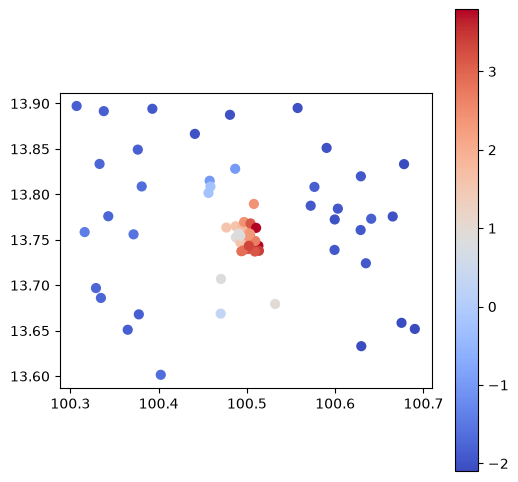

In [5]:
hotspots.plot(column="gi_zscore", cmap="coolwarm", legend=True, markersize=40, figsize=(6, 6))

## 4. Detect a Thai admin level and auto-plot it

`detect_level` accepts either a P-code string or a `(lat, lon)` pair and
auto-dispatches; `plot_level_map` renders a map zoomed to whatever level it
finds.

level=province, lat=13.7718, lon=100.6234


<Axes: title={'center': 'Province: Bangkok (TH10)'}>

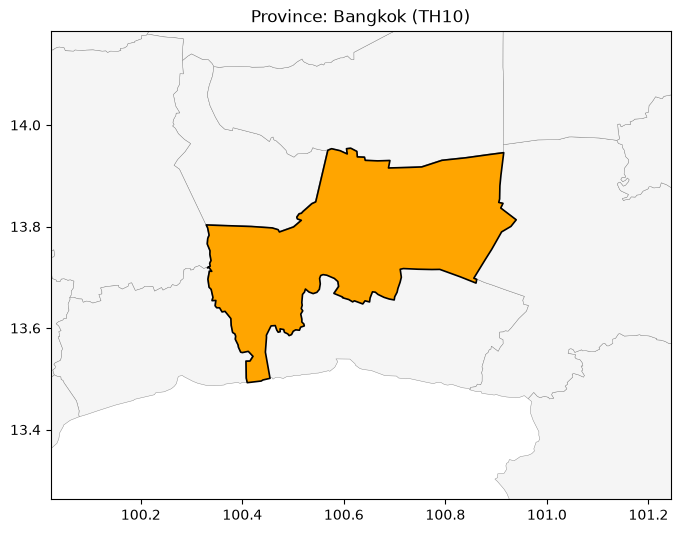

In [6]:
result = detect_level("TH10")  # Bangkok province P-code
print(f"level={result.level}, lat={result.lat:.4f}, lon={result.lon:.4f}")

plot_level_map("TH10")

`plot_level_map` also takes named `health_zone`/`province`/`district`/
`subdistrict` selectors instead of a raw P-code passed as `value`. `health_zone` is
the odd one out: a MoPH เขตสุขภาพ health zone is a *group* of provinces, not a
single admin unit, so it plots and zooms to every province in the zone together.

<Axes: title={'center': 'Health zone 1: 8 provinces'}>

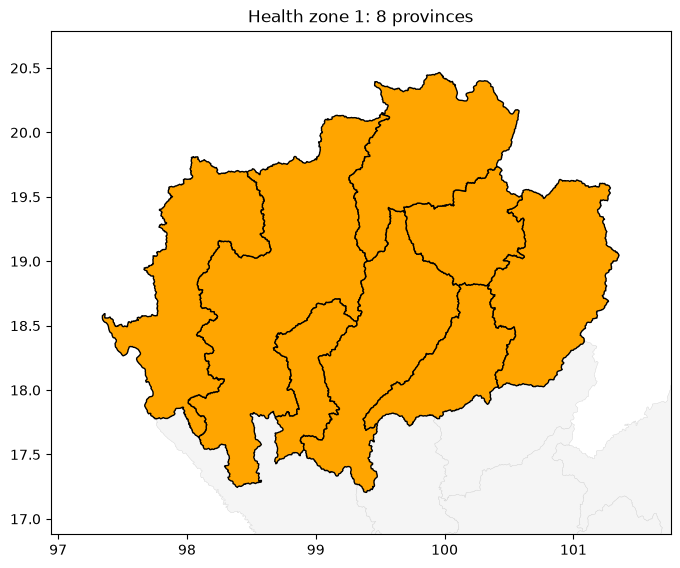

In [7]:
plot_level_map(health_zone=1)  # zone 1: 8 northern provinces, incl. Chiang Rai


`color` sets the highlighted unit's (or units', for `health_zone`) fill color;
`show_labels`/`label_fontsize`/`label_color` annotate each highlighted unit with its
name (size and text color) -- most useful for `health_zone`, which highlights several
provinces at once.

<Axes: title={'center': 'Health zone 1: 8 provinces'}>

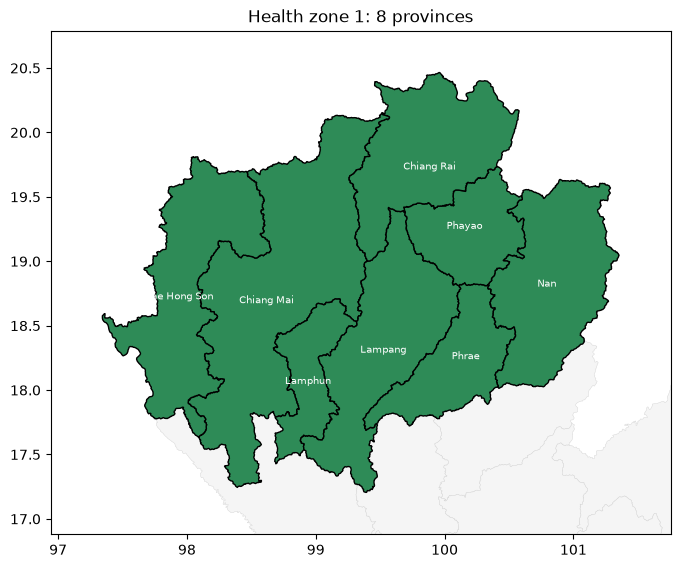

In [8]:
plot_level_map(
    health_zone=1, color="seagreen", show_labels=True, label_fontsize=7, label_color="white"
)


## 5. Reverse-geocode points to P-codes

`detect_point` is the inverse of `detect_province`/`detect_district`/
`detect_subdistrict`: given a DataFrame of `(lat, lon)` rows, it spatially
resolves which province/district/subdistrict each one falls inside.

In [9]:
located = detect_point(df)
located.groupby("subdistrict_en")["cases"].sum().sort_values(ascending=False).head(10)

subdistrict_en
Phraborom Maharatchawang    34
Bowon Niwet                 29
Wang Burapha Phirom         24
Wat Kanlaya                 22
Talat Noi                   18
Sirirat                     17
Sao Chingcha                16
Bang Khun Phrom             13
Wat Thepsirin               13
Ban Phan Thom               12
Name: cases, dtype: int64

## 6. P-code-tagged multi-disease data: describe, aggregate, and auto-plot anomalies

A larger, more realistic dataset: person-level records already tagged
with a subdistrict P-code (as real line-list data often does), spread
across multiple provinces over a 30-day window, with **two diseases**,
each with its own outbreak province and at least 30,000 cases. Thailand's
P-code scheme is nested -- subdistrict `"TH100101"` = district `"TH1001"`
+ 2 digits = province `"TH10"` + 2 more -- so the parent district/
province codes come from string slicing, no lookup needed. See
`examples/pcode_example.py` for the standalone script this section
mirrors.

In [10]:
def jittered_persons(s, n, start):
    return pd.DataFrame({
        "pcode": s["subdistrict_code"],
        "lat": rng.normal(s["lat"], 0.01, size=n),
        "long": rng.normal(s["lon"], 0.01, size=n),
        "date": start + pd.to_timedelta(rng.integers(0, 30, size=n), unit="D"),
    })

def make_disease_data(outbreak_province_en):
    rows = []
    baseline = subdistricts.groupby("province_code", as_index=False).first()
    for _, s in baseline.iterrows():
        rows.append(jittered_persons(s, rng.integers(20, 80), start))
    chosen = [by_province_en[by_province_en["province_en"] == p].sample(2, random_state=0) for p in background_provinces]
    for _, s in pd.concat(chosen, ignore_index=True).iterrows():
        rows.append(jittered_persons(s, rng.integers(1500, 2500), start))
    outbreak = by_province_en[by_province_en["province_en"] == outbreak_province_en].sample(1, random_state=1)
    for _, s in outbreak.iterrows():
        rows.append(jittered_persons(s, 8_000, start))
    return pd.concat(rows, ignore_index=True)

with open("../data/thailand_admin_centroids.json") as f:
    centroids = json.load(f)
subdistricts = pd.DataFrame(centroids["subdistricts"])
provinces = pd.DataFrame(centroids["provinces"])
by_province_en = subdistricts.merge(provinces[["province_code", "province_en"]], on="province_code")

background_provinces = ["Bangkok", "Chiang Mai", "Khon Kaen", "Nakhon Si Thammarat", "Songkhla", "Nakhon Ratchasima", "Chon Buri"]
# Each disease gets its own outbreak province, not in the background list -> isolated, disease-specific signal
disease_outbreak_province = {"Dengue": "Chiang Rai", "Influenza": "Surat Thani"}
start = pd.to_datetime("2024-05-01")

frames = []
for disease, outbreak_province_en in disease_outbreak_province.items():
    disease_df = make_disease_data(outbreak_province_en)
    disease_df["disease"] = disease
    frames.append(disease_df)
person_df = pd.concat(frames, ignore_index=True)
print(f"{len(person_df)} person records across {person_df['disease'].nunique()} diseases and {person_df['date'].dt.date.nunique()} days")
person_df.head()

81019 person records across 2 diseases and 30 days


,pcode,lat,long,date,disease
0,TH100101,13.739208,100.476578,2024-05-21,Dengue
1,TH100101,13.751241,100.492745,2024-05-30,Dengue
2,TH100101,13.752709,100.480666,2024-05-13,Dengue
3,TH100101,13.760089,100.478586,2024-05-11,Dengue
4,TH100101,13.752627,100.489922,2024-05-29,Dengue


### Data describe: cases per disease

In [11]:
print(person_df.groupby("disease").size().rename("persons"))
person_df.describe(include="all")

disease
Dengue       40930
Influenza    40089
Name: persons, dtype: int64


,pcode,lat,long,date,disease
count,81019,81019.000000,81019.000000,81019,81019
unique,93,NaN,NaN,NaN,2
top,TH570511,NaN,NaN,NaN,Dengue
freq,8000,NaN,NaN,NaN,40930
mean,NaN,13.571235,100.631133,2024-05-15 11:43:29.832261,NaN
min,NaN,6.400412,97.936900,2024-05-01 00:00:00,NaN
25%,NaN,9.420640,99.675055,2024-05-08 00:00:00,NaN
50%,NaN,13.816769,100.481526,2024-05-15 00:00:00,NaN
75%,NaN,16.819611,101.058033,2024-05-23 00:00:00,NaN
max,NaN,19.933204,104.876280,2024-05-30 00:00:00,NaN


### Aggregate by pcode to subdistrict / district / province

No spatial join needed here -- `pcode` is already known per row, so the
parent district/province codes come from string slicing and the rollup
is a plain `groupby`.

In [12]:
person_df["district_code"] = person_df["pcode"].str[:6]
person_df["province_code"] = person_df["pcode"].str[:4]

by_subdistrict = person_df.groupby("pcode").size()
by_district = person_df.groupby("district_code").size()
by_province = person_df.groupby("province_code").size()
print(f"{len(by_subdistrict)} subdistricts, {len(by_district)} districts, {len(by_province)} provinces")

93 subdistricts, 91 districts, 77 provinces


### No lat/long? Use `pcode_col` directly

`province_hotspots`/`district_hotspots`/`subdistrict_hotspots` accept
`pcode_col` as an alternative to `lon_col`/`lat_col`: pass the column you
already have and they skip `detect_point`'s spatial join entirely
(faster, and works with no lat/long columns present at all). A finer
code rolls up to whichever level you call automatically.

In [13]:
pcode_only = person_df[["pcode"]]  # lat/long columns intentionally dropped
prov_via_pcode = province_hotspots(pcode_only, pcode_col="pcode", k=5, permutations=99)
prov_via_pcode.sort_values("count", ascending=False)[["province_en", "count"]].head(5)

,province_en,count
38,Chiang Mai,8698
63,Nakhon Si Thammarat,8653
10,Chon Buri,8347
70,Songkhla,8272
28,Khon Kaen,8244


In [14]:
# province_col/district_col/subdistrict_col are identical synonyms for
# pcode_col, named for whichever level matches your column. subdistrict_col
# here needs no rollup (the pcode column is already subdistrict-grained);
# district_col rolls district_code up to province_hotspots's coarser level.
with warnings.catch_warnings():
    warnings.simplefilter("ignore", UserWarning)
    sub_via_subdistrict_col = subdistrict_hotspots(person_df[["pcode"]], subdistrict_col="pcode", k=5, permutations=49)
    prov_via_district_col = province_hotspots(person_df[["district_code"]], district_col="district_code", k=5, permutations=49)

print("subdistrict_hotspots(subdistrict_col='pcode'):")
display(sub_via_subdistrict_col.sort_values("count", ascending=False)[["subdistrict_en", "count"]].head(3))
print("province_hotspots(district_col='district_code'):")
display(prov_via_district_col.sort_values("count", ascending=False)[["province_en", "count"]].head(3))

subdistrict_hotspots(subdistrict_col='pcode'):


,subdistrict_en,count
6671,Thung,8000.0
4859,San Klang,8000.0
2917,Nong Bua,4651.0


province_hotspots(district_col='district_code'):


,province_en,count
38,Chiang Mai,8698
63,Nakhon Si Thammarat,8653
10,Chon Buri,8347


In [15]:
# Cross-check: pcode_col should agree with the lat/long path (small gaps
# expected -- a jittered point can land just outside its source polygon).
dengue_df = person_df[person_df["disease"] == "Dengue"]
with warnings.catch_warnings():
    warnings.simplefilter("ignore", UserWarning)
    dengue_via_pcode = province_hotspots(dengue_df, pcode_col="pcode", k=5, permutations=49)
    dengue_via_latlon = province_hotspots(dengue_df, lon_col="long", lat_col="lat", k=5, permutations=49)

compare = dengue_via_pcode[["province_code", "count"]].merge(
    dengue_via_latlon[["province_code", "count"]], on="province_code", suffixes=("_pcode_col", "_latlon")
)
matches = int((compare["count_pcode_col"] == compare["count_latlon"]).sum())
print(f"{matches}/{len(compare)} provinces match exactly between pcode_col and lat/long")

63/77 provinces match exactly between pcode_col and lat/long


### Detect anomalies at every level and auto-plot each result

`province_hotspots`/`district_hotspots`/`subdistrict_hotspots` take the
same point-level data directly (lat/long), reverse-geocode it with
`detect_point`, and aggregate onto *every* unit at that level.
`plot_hotspots` then auto-plots the result as a choropleth, colored by
`gi_zscore` (continuous, diverging, centered at zero) rather than the
`hotspot` significance flag -- with one dominant outbreak among many
small/baseline counts, that flag can be unreliable even when `gi_zscore`
correctly ranks the outbreak highest (see `level_hotspots.py`).

Text(0.5, 1.0, 'Dengue: province-level gi_zscore')

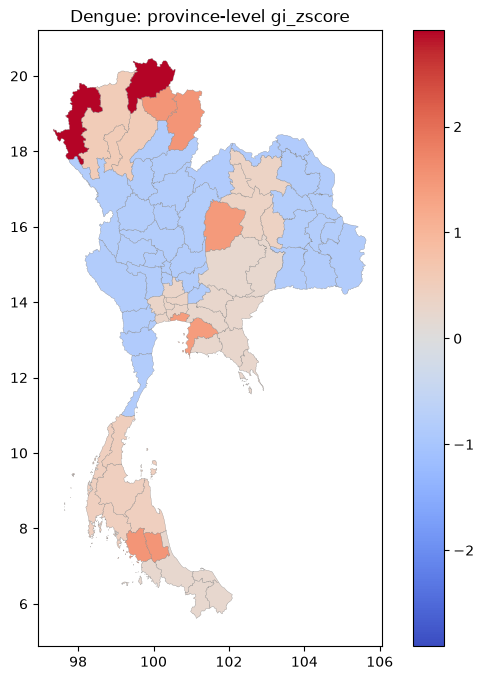

In [16]:
dengue_df = person_df[person_df["disease"] == "Dengue"]
with warnings.catch_warnings():
    warnings.simplefilter("ignore", UserWarning)  # libpysal disconnected-components notice
    dengue_province = province_hotspots(dengue_df, lon_col="long", lat_col="lat", k=5, permutations=499)

plot_hotspots(dengue_province).set_title("Dengue: province-level gi_zscore")

Text(0.5, 1.0, 'Influenza: province-level gi_zscore')

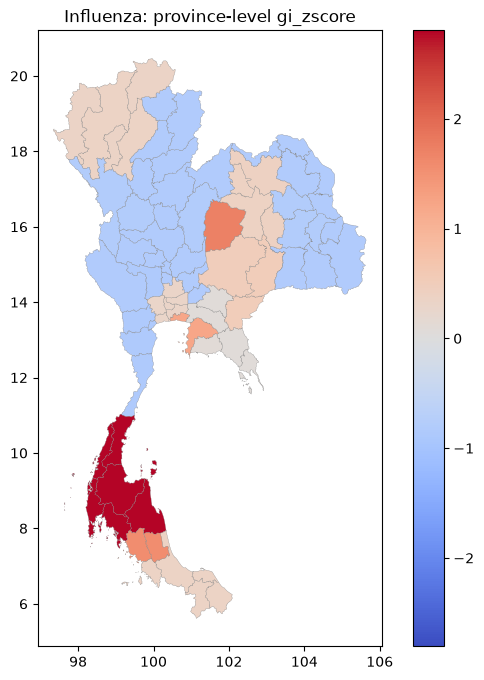

In [17]:
influenza_df = person_df[person_df["disease"] == "Influenza"]
with warnings.catch_warnings():
    warnings.simplefilter("ignore", UserWarning)
    influenza_province = province_hotspots(influenza_df, lon_col="long", lat_col="lat", k=5, permutations=499)

plot_hotspots(influenza_province).set_title("Influenza: province-level gi_zscore")

Text(0.5, 1.0, 'Dengue: district-level gi_zscore')

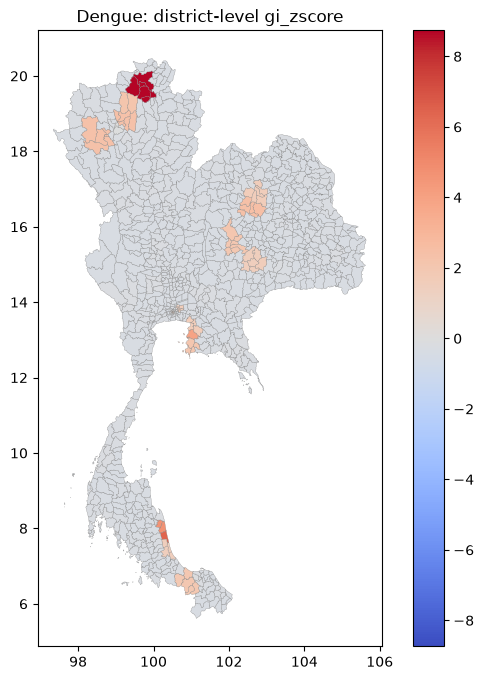

In [18]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore", UserWarning)
    dengue_district = district_hotspots(dengue_df, lon_col="long", lat_col="lat", k=5, permutations=199)

plot_hotspots(dengue_district).set_title("Dengue: district-level gi_zscore")

Text(0.5, 1.0, 'Dengue: subdistrict-level gi_zscore')

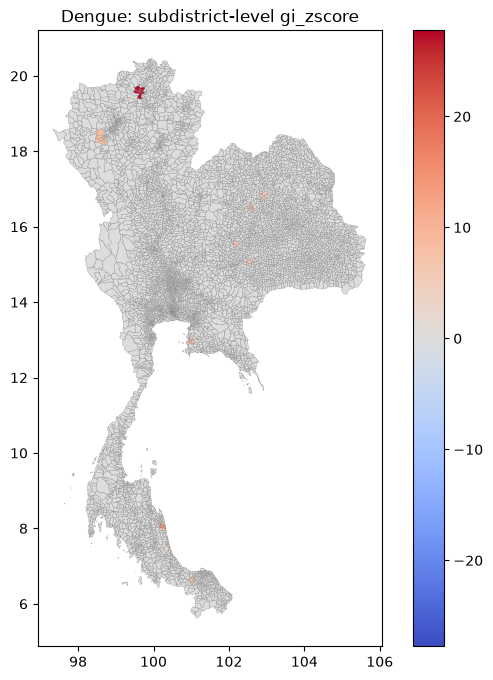

In [19]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore", UserWarning)
    dengue_subdistrict = subdistrict_hotspots(dengue_df, lon_col="long", lat_col="lat", k=5, permutations=99)

plot_hotspots(dengue_subdistrict).set_title("Dengue: subdistrict-level gi_zscore")

## 7. Zoom into one region: health_zone/province/district selectors

`plot_hotspots` takes the same `health_zone`/`province`/`district` selectors as
`plot_level_map` (pass at most one) to restrict the choropleth to one region and
zoom to its bounds, instead of showing the whole country. A result can only be
filtered at its own grain or coarser -- a `district_hotspots` result can be
filtered by `district` or `province`, but not by a level finer than district.

Text(0.5, 1.0, 'Dengue: subdistrict-level gi_zscore (health zone 1)')

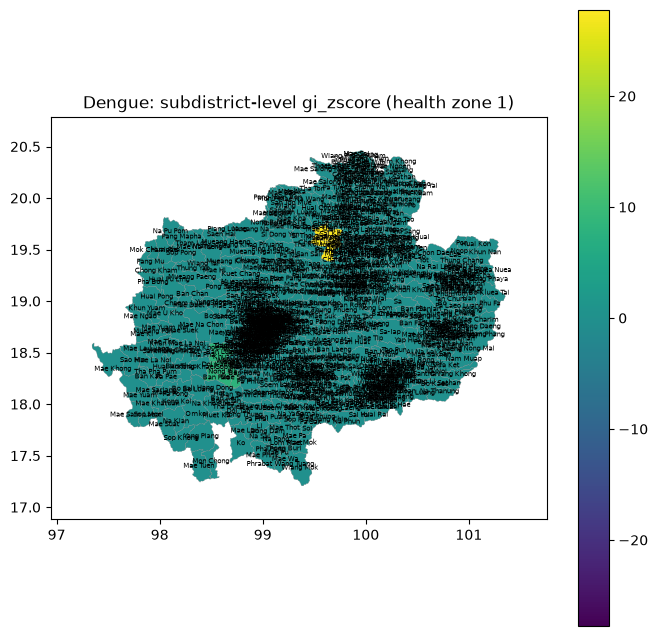

In [20]:
# cmap picks the colormap; show_labels/label_fontsize/label_color annotate each
# subdistrict with its name (crowded at this grain, but works the same
# way at province/district grain).
plot_hotspots(
    dengue_subdistrict, health_zone=1, cmap="viridis",
    show_labels=True, label_fontsize=5, label_color="black",
).set_title(
    "Dengue: subdistrict-level gi_zscore (health zone 1)"
)


Text(0.5, 1.0, 'Dengue: district-level gi_zscore (Chiang Rai province)')

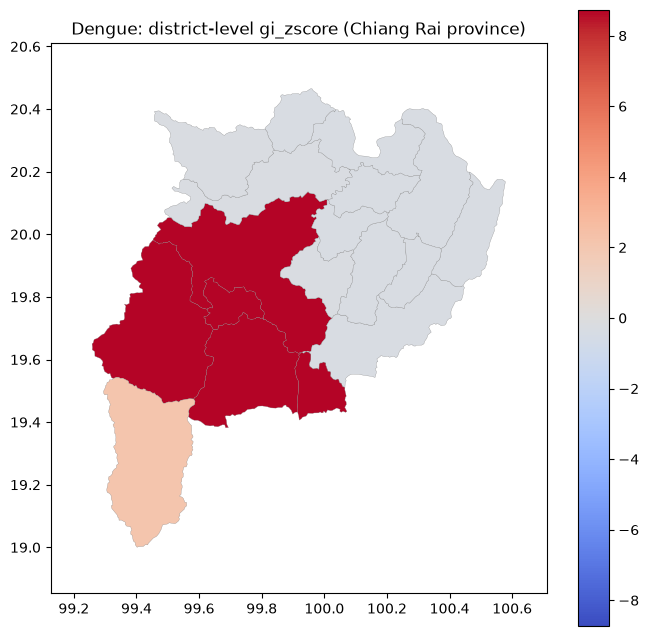

In [21]:
# Same idea at district grain, zoomed to a single province.
plot_hotspots(dengue_district, province="TH57").set_title(
    "Dengue: district-level gi_zscore (Chiang Rai province)"
)


## 8. Categorical hotspot/coldspot/not-significant coloring

Plotting `value_col="hotspot"` (the discrete significance flag: 1/-1/0) instead of
the continuous `gi_zscore` switches `plot_hotspots` to categorical coloring --
`cmap` is ignored in favor of `hotspot_color`/`coldspot_color`/`not_significant_color`,
each independently adjustable, with a matching legend.

Text(0.5, 1.0, 'Dengue: province-level hotspot flag')

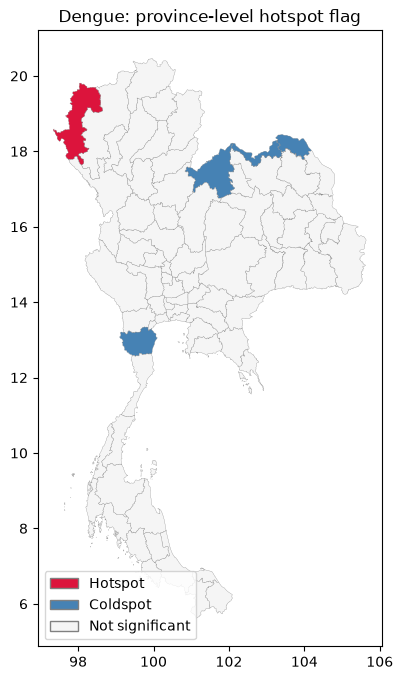

In [22]:
plot_hotspots(
    dengue_province, value_col="hotspot", hotspot_color="crimson", coldspot_color="steelblue"
).set_title("Dengue: province-level hotspot flag")


## 9. Spatiotemporal hotspots

Bin points by day/week/month and run Getis-Ord Gi* independently within
each bin, so a hotspot in one period isn't diluted by activity in another.

In [23]:
by_day = spatiotemporal_hotspots(
    df, time_col="reported_at", value_col="cases", timeframe="day", k=5, permutations=199
)
by_day.groupby("time_bin")["hotspot"].apply(lambda s: (s == 1).sum()).rename("hotspot_points")

time_bin
2024-06-01    3
2024-06-02    7
2024-06-03    8
2024-06-04    7
2024-06-05    1
Name: hotspot_points, dtype: int64

### Compare timeframe granularity: day / week / month

The same persistent spatial cluster is detectable at any temporal granularity --
`timeframe="day"`/`"week"`/`"month"` just bin it differently in time. `df` only
spans 5 days, too sparse for week/month bins to say much, so this uses a longer,
denser 9-week version of the same cluster-plus-background shape. Finer bins (day)
resolve short-lived signals more precisely but need more points per bin -- see the
k+1-per-bin floor, which skips sparse bins with a `UserWarning`; coarser bins
(month) need less density but blur together anything that shifts within a bin.

In [24]:
n_days = 63  # 9 weeks
time_cluster = pd.DataFrame({
    "lon": rng.normal(100.50, 0.01, size=n_days * 8),
    "lat": rng.normal(13.75, 0.01, size=n_days * 8),
    "cases": rng.poisson(8, size=n_days * 8),
})
time_background = pd.DataFrame({
    "lon": rng.uniform(100.3, 100.7, size=n_days * 8),
    "lat": rng.uniform(13.6, 13.9, size=n_days * 8),
    "cases": rng.poisson(1, size=n_days * 8),
})
time_df = pd.concat([time_cluster, time_background], ignore_index=True)
time_df["reported_at"] = pd.to_datetime("2024-05-01") + pd.to_timedelta(
    rng.integers(0, n_days, size=len(time_df)), unit="D"
)

for timeframe in ("day", "week", "month"):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", UserWarning)  # sparse-bin skip notice
        by_timeframe = spatiotemporal_hotspots(
            time_df, time_col="reported_at", value_col="cases", timeframe=timeframe, k=5, permutations=199
        )
    n_bins = by_timeframe["time_bin"].nunique()
    n_hot = (by_timeframe["hotspot"] == 1).sum()
    print(f"timeframe={timeframe!r}: {n_bins} bin(s) covered, {n_hot} hotspot point-observation(s)")


timeframe='day': 63 bin(s) covered, 378 hotspot point-observation(s)
timeframe='week': 10 bin(s) covered, 238 hotspot point-observation(s)


timeframe='month': 3 bin(s) covered, 231 hotspot point-observation(s)


Text(0.5, 1.0, 'Cases: week 2024-04-29/2024-05-05 gi_zscore')

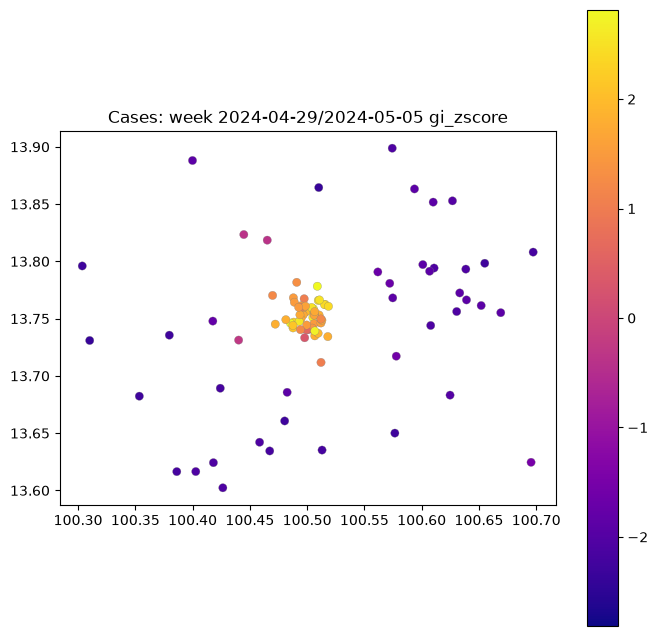

In [25]:
# spatiotemporal_hotspots stacks every bin's points into one
# GeoDataFrame, so filter to a single time_bin before plotting a
# readable map -- here, the first week's cluster.
by_week = spatiotemporal_hotspots(
    time_df, time_col="reported_at", value_col="cases", timeframe="week", k=5, permutations=199
)
first_week = sorted(by_week["time_bin"].unique())[0]
plot_hotspots(by_week[by_week["time_bin"] == first_week], cmap="plasma").set_title(
    f"Cases: week {first_week} gi_zscore"
)


### Timeframe detail: one block per granularity

Bin `time_df`'s persistent Bangkok cluster at day/week/month grain, aggregate that
bin to both province and district level, and plot the district-level result (the
finer, more informative view once there's enough data -- see `level_hotspots.py`'s
degenerate-significance caveat for sparse finer levels). Kept as three separate
blocks rather than a loop so each granularity's point count and result table are
easy to compare side by side.

In [26]:
def print_top(result, name_col, label, value_col="count", n=5):
    """Top-n rows by gi_zscore, with the aggregated value/z-score/p-value/significance flag."""
    cols = [name_col, value_col, "gi_zscore", "gi_pvalue", "hotspot"]
    print(f"{label} -- top {n} by gi_zscore:")
    print(result.sort_values("gi_zscore", ascending=False).head(n)[cols].to_string(index=False))


def top_code(result, code_col):
    """P-code of the top gi_zscore row -- used to zoom a finer-level plot into
    whichever unit the coarser level flagged, without hardcoding a P-code."""
    return result.sort_values("gi_zscore", ascending=False).iloc[0][code_col]


#### Day

Day '2024-05-01' (21 points), provinces -- top 5 by gi_zscore:
 province_en  cases  gi_zscore  gi_pvalue  hotspot
     Bangkok  106.0   3.537219      0.055        0
Samut Prakan    3.0   3.537219      0.055        0
Samut Sakhon    0.0   3.537219      0.010        1
Pathum Thani    0.0   3.537219      0.010        1
   Chon Buri    0.0   3.537219      0.010        1
Day '2024-05-01', districts -- top 5 by gi_zscore:
         district_en  cases  gi_zscore  gi_pvalue  hotspot
         Phra Nakhon   19.0  20.564948      0.005        1
               Dusit   37.0  20.564948      0.005        1
          Bang Phlat    0.0  20.564948      0.005        1
         Ratchathewi    0.0  16.777060      0.005        1
Pom Prap Sattru Phai   37.0  13.434805      0.010        1
Day '2024-05-01', subdistricts -- top 5 by gi_zscore:
subdistrict_en  cases  gi_zscore  gi_pvalue  hotspot
Khlong Mahanak    0.0  32.520016      0.005        1
         Dusit   21.0  32.520016      0.005        1
       Ban Ba

Text(0.5, 1.0, 'Cases: 2024-05-01, Bangkok districts, gi_zscore')

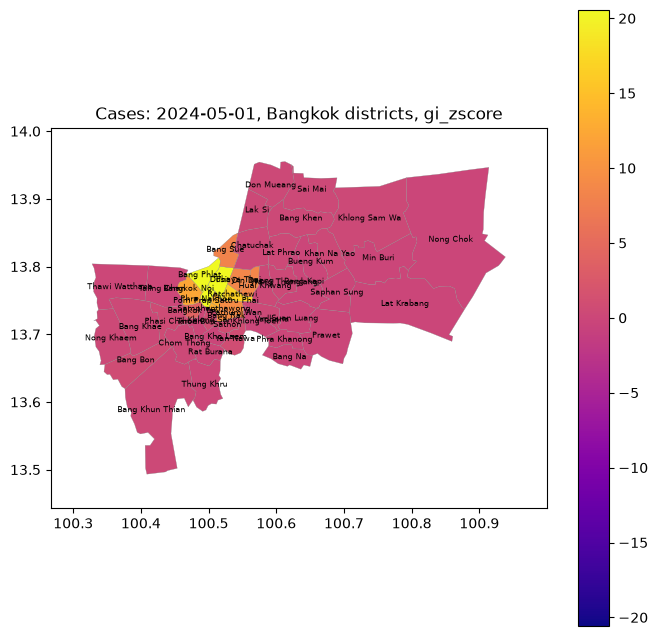

In [27]:
day_binned = time_bin_label(time_df["reported_at"], timeframe="day")
first_day = sorted(day_binned.unique())[0]
day_df = time_df[day_binned == first_day]
with warnings.catch_warnings():
    warnings.simplefilter("ignore", UserWarning)
    day_province = province_hotspots(day_df, value_col="cases", k=5, permutations=199)
    day_district = district_hotspots(day_df, value_col="cases", k=5, permutations=199)
    day_subdistrict = subdistrict_hotspots(day_df, value_col="cases", k=5, permutations=199)

print_top(day_province, "province_en", f"Day {first_day!r} ({len(day_df)} points), provinces", value_col="cases")
print_top(day_district, "district_en", f"Day {first_day!r}, districts", value_col="cases")
print_top(day_subdistrict, "subdistrict_en", f"Day {first_day!r}, subdistricts", value_col="cases")

plot_hotspots(
    day_district, province="TH10", cmap="plasma", show_labels=True, label_fontsize=6, label_color="black"
).set_title(f"Cases: {first_day}, Bangkok districts, gi_zscore")


Text(0.5, 1.0, 'Cases: 2024-05-01, subdistrict-level gi_zscore')

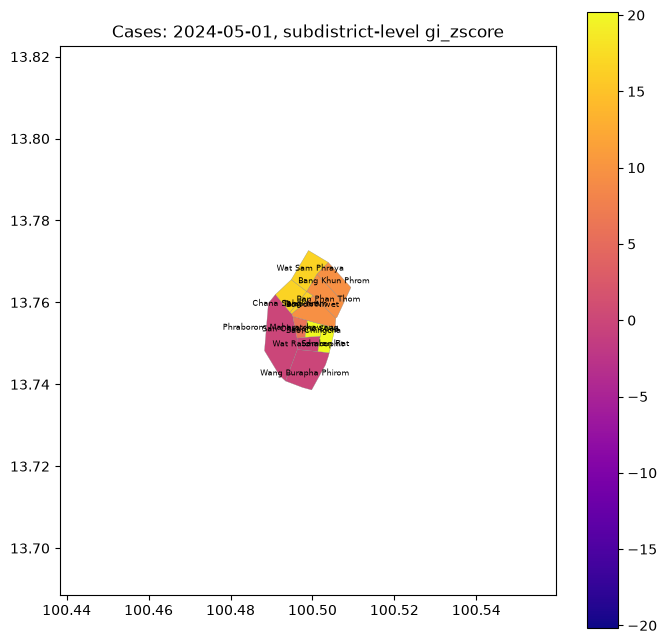

In [28]:
plot_hotspots(
    day_subdistrict, district=top_code(day_district, "district_code"), cmap="plasma",
    show_labels=True, label_fontsize=6, label_color="black",
).set_title(f"Cases: {first_day}, subdistrict-level gi_zscore")


#### Week

Week '2024-04-29/2024-05-05' (94 points), provinces -- top 5 by gi_zscore:
 province_en  cases  gi_zscore  gi_pvalue  hotspot
     Bangkok  383.0   3.494336      0.005        1
Pathum Thani    0.0   3.494336      0.005        1
Samut Prakan    4.0   3.494336      0.005        1
Samut Sakhon    0.0   3.494336      0.005        1
   Chon Buri    0.0   3.474852      0.005        1
Week '2024-04-29/2024-05-05', districts -- top 5 by gi_zscore:
   district_en  cases  gi_zscore  gi_pvalue  hotspot
   Phra Nakhon  107.0  26.700687      0.005        1
    Bang Phlat    8.0  22.067478      0.005        1
         Dusit   59.0  20.116654      0.005        1
   Bangkok Noi   24.0  19.872801      0.005        1
Samphanthawong   33.0  18.572251      0.005        1
Week '2024-04-29/2024-05-05', subdistricts -- top 5 by gi_zscore:
          subdistrict_en  cases  gi_zscore  gi_pvalue  hotspot
                Pom Prap   25.0  37.975517      0.005        1
          Samphanthawong   20.0  33.516663    

Text(0.5, 1.0, 'Cases: week 2024-04-29/2024-05-05, province-level gi_zscore')

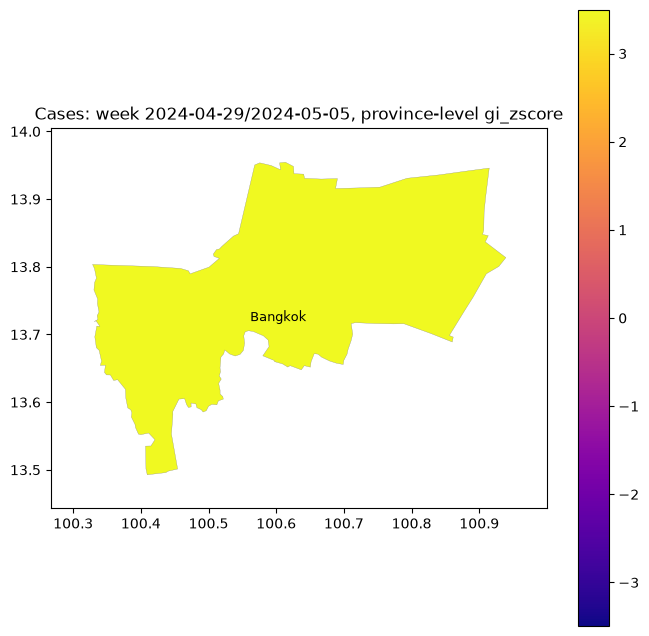

In [29]:
week_binned = time_bin_label(time_df["reported_at"], timeframe="week")
first_week_2 = sorted(week_binned.unique())[0]
week_df = time_df[week_binned == first_week_2]
with warnings.catch_warnings():
    warnings.simplefilter("ignore", UserWarning)
    week_province = province_hotspots(week_df, value_col="cases", k=5, permutations=199)
    week_district = district_hotspots(week_df, value_col="cases", k=5, permutations=199)
    week_subdistrict = subdistrict_hotspots(week_df, value_col="cases", k=5, permutations=199)

print_top(week_province, "province_en", f"Week {first_week_2!r} ({len(week_df)} points), provinces", value_col="cases")
print_top(week_district, "district_en", f"Week {first_week_2!r}, districts", value_col="cases")
print_top(week_subdistrict, "subdistrict_en", f"Week {first_week_2!r}, subdistricts", value_col="cases")

plot_hotspots(
    week_province, province="TH10", cmap="plasma", show_labels=True, label_fontsize=9, label_color="black"
).set_title(f"Cases: week {first_week_2}, province-level gi_zscore")


Text(0.5, 1.0, 'Cases: week 2024-04-29/2024-05-05, Bangkok districts, gi_zscore')

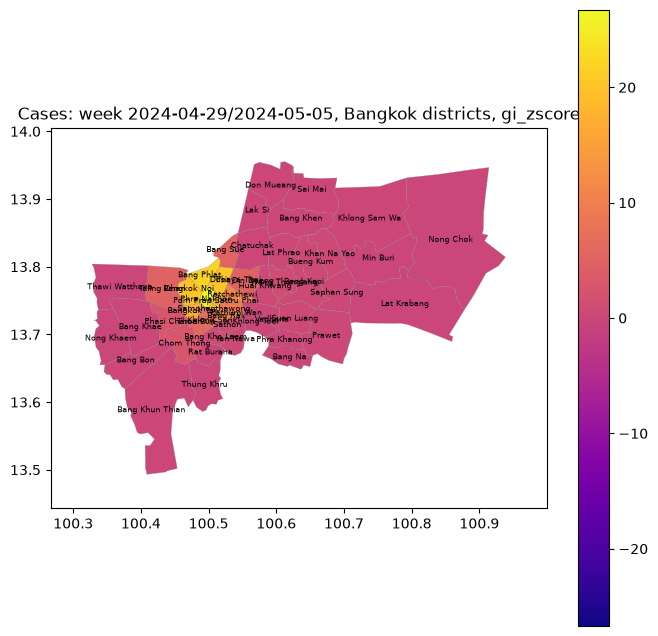

In [30]:
plot_hotspots(
    week_district, province="TH10", cmap="plasma", show_labels=True, label_fontsize=6, label_color="black"
).set_title(f"Cases: week {first_week_2}, Bangkok districts, gi_zscore")


Text(0.5, 1.0, 'Cases: week 2024-04-29/2024-05-05, subdistrict-level gi_zscore')

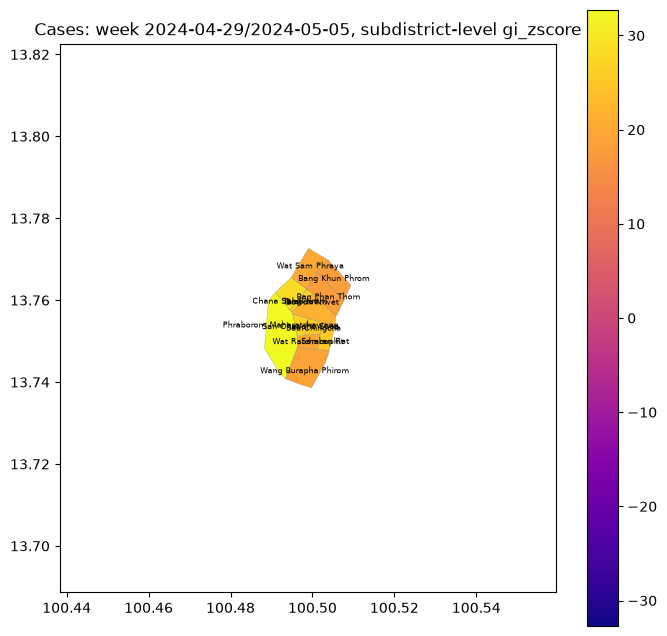

In [31]:
plot_hotspots(
    week_subdistrict, district=top_code(week_district, "district_code"), cmap="plasma",
    show_labels=True, label_fontsize=6, label_color="black",
).set_title(f"Cases: week {first_week_2}, subdistrict-level gi_zscore")


#### Month

Month '2024-05' (490 points), provinces -- top 5 by gi_zscore:
 province_en  cases  gi_zscore  gi_pvalue  hotspot
     Bangkok 2042.0   3.557110      0.005        1
Samut Sakhon   12.0   3.557110      0.005        1
Samut Prakan   26.0   3.551628      0.005        1
Pathum Thani    0.0   3.529699      0.005        1
  Nonthaburi   28.0   3.509597      0.010        1
Month '2024-05', districts -- top 5 by gi_zscore:
         district_en  cases  gi_zscore  gi_pvalue  hotspot
         Phra Nakhon  777.0  22.262968      0.005        1
         Bangkok Noi  198.0  20.339603      0.005        1
          Bang Phlat   49.0  20.130542      0.005        1
      Samphanthawong  102.0  18.890111      0.005        1
Pom Prap Sattru Phai  344.0  18.374426      0.005        1
Month '2024-05', subdistricts -- top 5 by gi_zscore:
          subdistrict_en  cases  gi_zscore  gi_pvalue  hotspot
Phraborom Maharatchawang  187.0  49.863778      0.005        1
        Wat Ratchabophit   48.0  45.458316      

Text(0.5, 1.0, 'Cases: 2024-05, province-level gi_zscore')

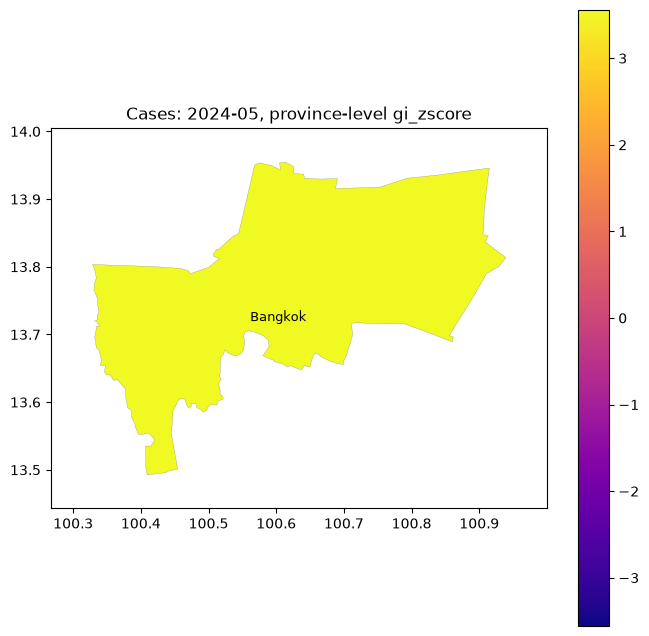

In [32]:
month_binned = time_bin_label(time_df["reported_at"], timeframe="month")
first_month = sorted(month_binned.unique())[0]
month_df_bangkok = time_df[month_binned == first_month]
with warnings.catch_warnings():
    warnings.simplefilter("ignore", UserWarning)
    month_province = province_hotspots(month_df_bangkok, value_col="cases", k=5, permutations=199)
    month_district = district_hotspots(month_df_bangkok, value_col="cases", k=5, permutations=199)
    month_subdistrict = subdistrict_hotspots(month_df_bangkok, value_col="cases", k=5, permutations=199)

print_top(month_province, "province_en", f"Month {first_month!r} ({len(month_df_bangkok)} points), provinces", value_col="cases")
print_top(month_district, "district_en", f"Month {first_month!r}, districts", value_col="cases")
print_top(month_subdistrict, "subdistrict_en", f"Month {first_month!r}, subdistricts", value_col="cases")

plot_hotspots(
    month_province, province="TH10", cmap="plasma", show_labels=True, label_fontsize=9, label_color="black"
).set_title(f"Cases: {first_month}, province-level gi_zscore")


Text(0.5, 1.0, 'Cases: 2024-05, Bangkok districts, gi_zscore')

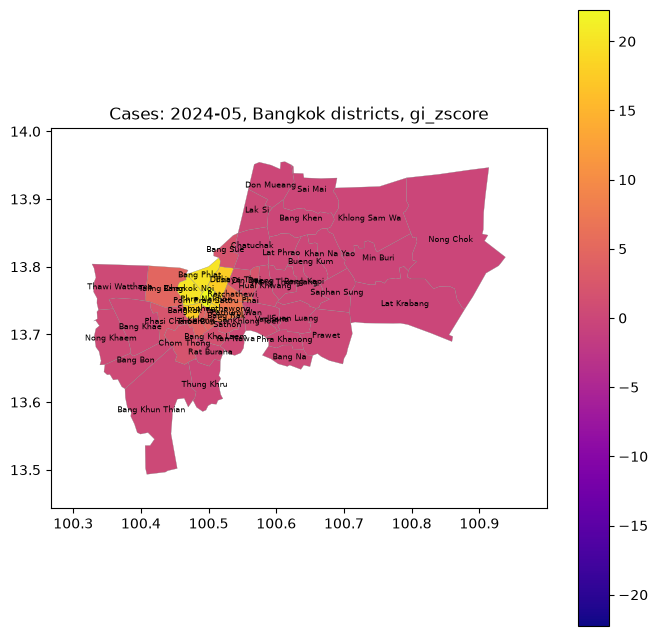

In [33]:
plot_hotspots(
    month_district, province="TH10", cmap="plasma", show_labels=True, label_fontsize=6, label_color="black"
).set_title(f"Cases: {first_month}, Bangkok districts, gi_zscore")


Text(0.5, 1.0, 'Cases: 2024-05, subdistrict-level gi_zscore')

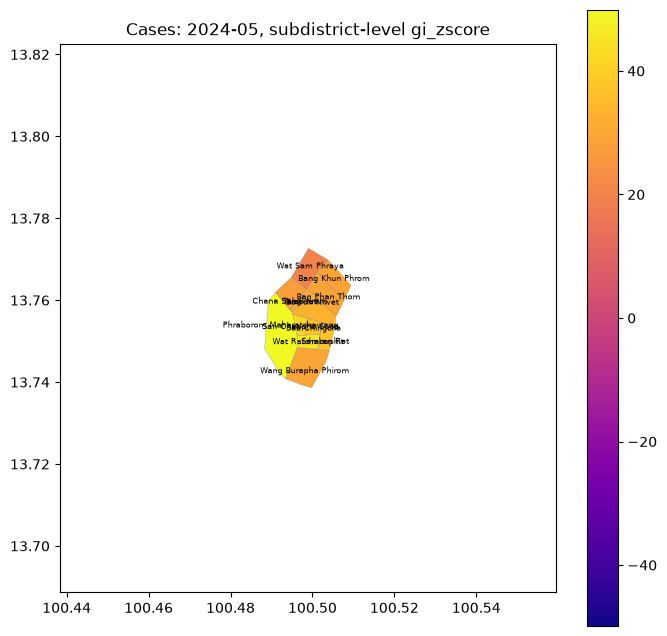

In [34]:
plot_hotspots(
    month_subdistrict, district=top_code(month_district, "district_code"), cmap="plasma",
    show_labels=True, label_fontsize=6, label_color="black",
).set_title(f"Cases: {first_month}, subdistrict-level gi_zscore")


### Multi-location detail: one block per outbreak

Real outbreaks don't stay in one place. `moving_df` has a *different* outbreak
province active each month -- Chiang Mai in May, Surat Thani in June, Khon Kaen in
July -- against the same central-Bangkok background used in `make_multi_province_outbreak`
(kept geographically distant from all three outbreak provinces so each month's
Getis-Ord neighborhood stays cleanly separated instead of smoothing the outbreak's
z-score into its real, zero-count geographic neighbors). Each block below prints
the detailed province and district tables and plots both levels, zoomed to that
month's outbreak province.

In [35]:
with open("../data/thailand_admin_centroids.json") as f:
    all_provinces = pd.DataFrame(json.load(f)["provinces"])

moving_background_codes = [
    "TH11", "TH12", "TH13", "TH14", "TH15", "TH16", "TH17", "TH18", "TH19",
]
moving_background = all_provinces[all_provinces["province_code"].isin(moving_background_codes)]
moving_month_starts = pd.to_datetime(["2024-05-01", "2024-06-01", "2024-07-01"])
moving_outbreak_en = ["Chiang Mai", "Surat Thani", "Khon Kaen"]

moving_frames = []
for month_start, outbreak_en in zip(moving_month_starts, moving_outbreak_en):
    for _, p in moving_background.iterrows():
        n = rng.integers(2, 8)
        moving_frames.append(pd.DataFrame({
            "lon": rng.normal(p["lon"], 0.05, size=n),
            "lat": rng.normal(p["lat"], 0.05, size=n),
            "reported_at": month_start + pd.to_timedelta(rng.integers(0, 28, size=n), unit="D"),
        }))
    outbreak = all_provinces.loc[all_provinces["province_en"] == outbreak_en].iloc[0]
    moving_frames.append(pd.DataFrame({
        "lon": rng.normal(outbreak["lon"], 0.05, size=60),
        "lat": rng.normal(outbreak["lat"], 0.05, size=60),
        "reported_at": month_start + pd.to_timedelta(rng.integers(0, 28, size=60), unit="D"),
    }))
moving_df = pd.concat(moving_frames, ignore_index=True)
moving_df["month"] = time_bin_label(moving_df["reported_at"], timeframe="month")


#### May: Chiang Mai

May 2024 (expect Chiang Mai), provinces -- top 5 by gi_zscore:
 province_en  count  gi_zscore  gi_pvalue  hotspot
  Chiang Mai   60.0   3.165766      0.005        1
Mae Hong Son    0.0   3.165766      0.100        0
     Lampang    0.0   3.165766      0.100        0
  Chiang Rai    0.0   3.165766      0.100        0
     Lamphun    0.0   3.165766      0.100        0
May 2024, Chiang Mai districts -- top 5 by gi_zscore:
    district_en  count  gi_zscore  gi_pvalue  hotspot
        Samoeng   39.0  16.980165      0.005        1
       Mae Wang   16.0  16.693954      0.005        1
        Mae Rim    1.0  12.400800      0.005        1
      Mae Taeng    0.0  11.255959      0.005        1
Galyani Vadhana    0.0  10.969749      0.005        1
May 2024, Chiang Mai subdistricts -- top 5 by gi_zscore:
subdistrict_en  count  gi_zscore  gi_pvalue  hotspot
       Bo Kaeo    1.0  43.758804      0.005        1
   Samoeng Tai   38.0  37.742780      0.010        1
    Pong Yaeng    1.0  36.883348     

Text(0.5, 1.0, 'Cases: May 2024, Chiang Mai province-level gi_zscore')

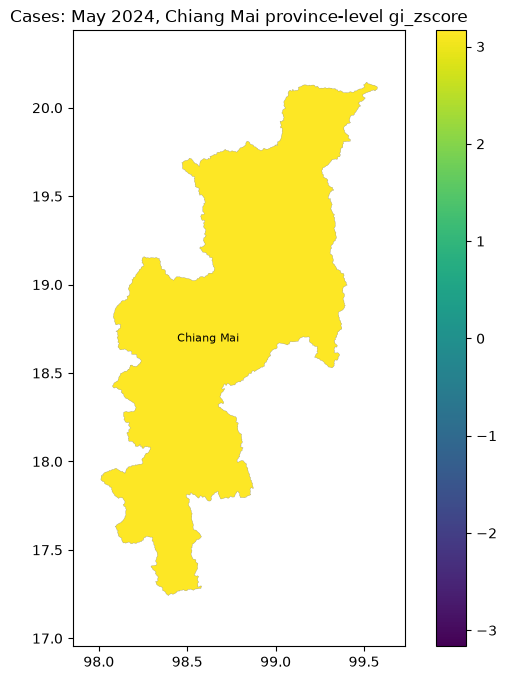

In [36]:
may_df = moving_df[moving_df["month"] == "2024-05"]
with warnings.catch_warnings():
    warnings.simplefilter("ignore", UserWarning)
    may_province = province_hotspots(may_df, k=5, permutations=199)
    may_district = district_hotspots(may_df, k=5, permutations=199)
    may_subdistrict = subdistrict_hotspots(may_df, k=5, permutations=199)

print_top(may_province, "province_en", "May 2024 (expect Chiang Mai), provinces")
print_top(may_district, "district_en", "May 2024, Chiang Mai districts")
print_top(may_subdistrict, "subdistrict_en", "May 2024, Chiang Mai subdistricts")

plot_hotspots(
    may_province, province="TH50", cmap="viridis", show_labels=True, label_fontsize=8, label_color="black"
).set_title("Cases: May 2024, Chiang Mai province-level gi_zscore")


Text(0.5, 1.0, 'Cases: May 2024, Chiang Mai districts, gi_zscore')

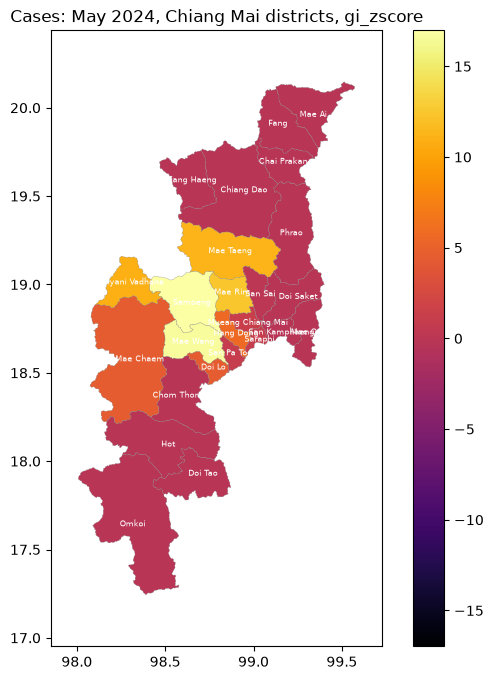

In [37]:
plot_hotspots(
    may_district, province="TH50", cmap="inferno", show_labels=True, label_fontsize=6, label_color="white"
).set_title("Cases: May 2024, Chiang Mai districts, gi_zscore")


Text(0.5, 1.0, 'Cases: May 2024, Chiang Mai subdistrict-level gi_zscore')

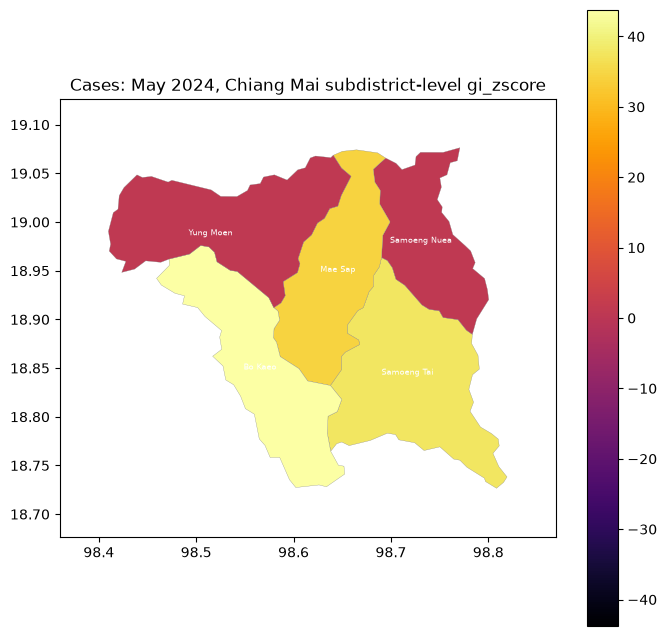

In [38]:
plot_hotspots(
    may_subdistrict, district=top_code(may_district, "district_code"), cmap="inferno",
    show_labels=True, label_fontsize=6, label_color="white",
).set_title("Cases: May 2024, Chiang Mai subdistrict-level gi_zscore")


#### June: Surat Thani

June 2024 (expect Surat Thani), provinces -- top 5 by gi_zscore:
        province_en  count  gi_zscore  gi_pvalue  hotspot
             Ranong    0.0   3.196666      0.065        0
           Chumphon    0.0   3.196666      0.065        0
Nakhon Si Thammarat    0.0   3.196666      0.075        0
              Krabi    0.0   3.196666      0.075        0
           Phangnga    0.0   3.196666      0.075        0
June 2024, Surat Thani districts -- top 5 by gi_zscore:
     district_en  count  gi_zscore  gi_pvalue  hotspot
        Phunphin   39.0  16.350235      0.005        1
Khiri Rat Nikhom   21.0  16.350235      0.015        1
       Vibhavadi    0.0  16.350235      0.005        1
          Chaiya    0.0  10.565315      0.015        1
        Khian Sa    0.0  10.565315      0.015        1
June 2024, Surat Thani subdistricts -- top 5 by gi_zscore:
subdistrict_en  count  gi_zscore  gi_pvalue  hotspot
    Bang Duean    4.0  64.041526      0.005        1
   Bang Maduea   13.0  61.252212    

Text(0.5, 1.0, 'Cases: June 2024, Surat Thani province-level gi_zscore')

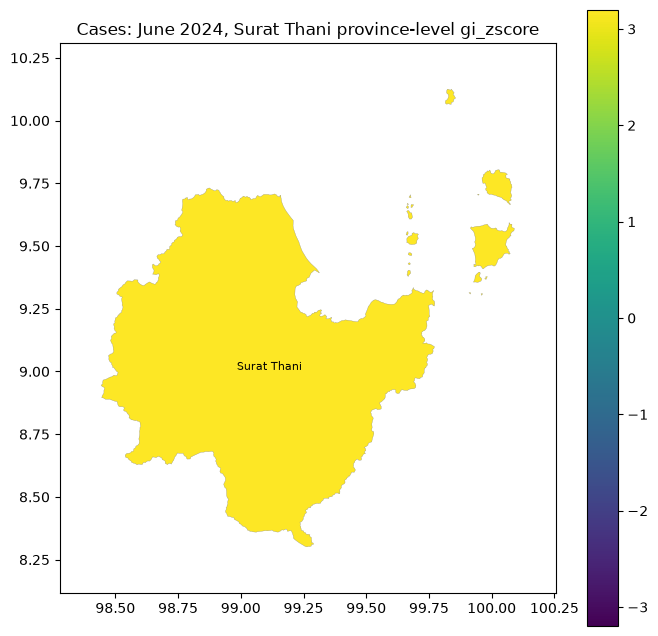

In [39]:
june_df = moving_df[moving_df["month"] == "2024-06"]
with warnings.catch_warnings():
    warnings.simplefilter("ignore", UserWarning)
    june_province = province_hotspots(june_df, k=5, permutations=199)
    june_district = district_hotspots(june_df, k=5, permutations=199)
    june_subdistrict = subdistrict_hotspots(june_df, k=5, permutations=199)

print_top(june_province, "province_en", "June 2024 (expect Surat Thani), provinces")
print_top(june_district, "district_en", "June 2024, Surat Thani districts")
print_top(june_subdistrict, "subdistrict_en", "June 2024, Surat Thani subdistricts")

plot_hotspots(
    june_province, province="TH84", cmap="viridis", show_labels=True, label_fontsize=8, label_color="black"
).set_title("Cases: June 2024, Surat Thani province-level gi_zscore")


Text(0.5, 1.0, 'Cases: June 2024, Surat Thani districts, gi_zscore')

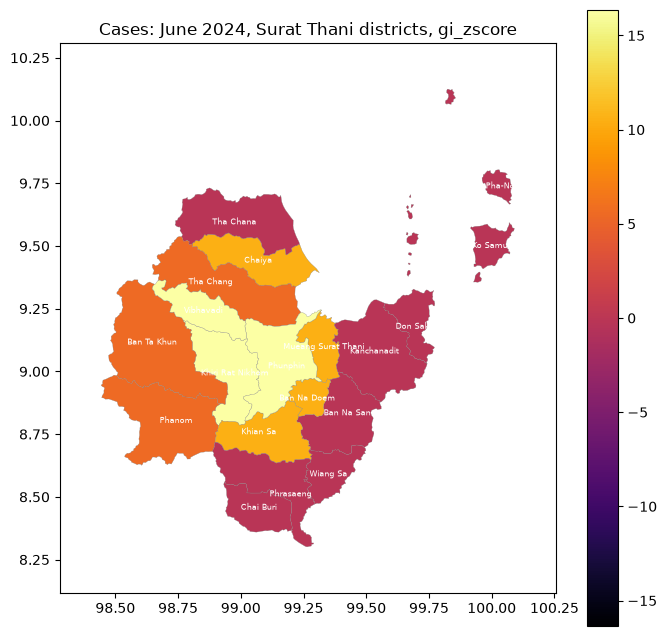

In [40]:
plot_hotspots(
    june_district, province="TH84", cmap="inferno", show_labels=True, label_fontsize=6, label_color="white"
).set_title("Cases: June 2024, Surat Thani districts, gi_zscore")


Text(0.5, 1.0, 'Cases: June 2024, Surat Thani subdistrict-level gi_zscore')

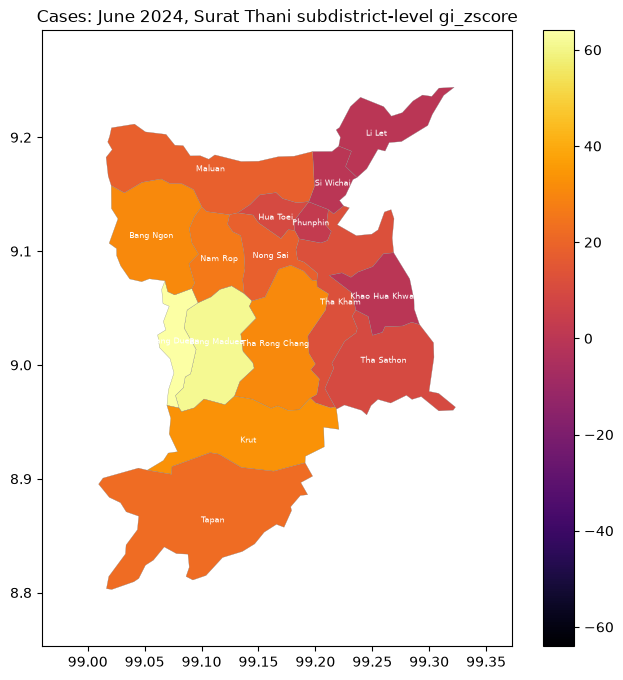

In [41]:
plot_hotspots(
    june_subdistrict, district=top_code(june_district, "district_code"), cmap="inferno",
    show_labels=True, label_fontsize=6, label_color="white",
).set_title("Cases: June 2024, Surat Thani subdistrict-level gi_zscore")


#### July: Khon Kaen

July 2024 (expect Khon Kaen), provinces -- top 5 by gi_zscore:
     province_en  count  gi_zscore  gi_pvalue  hotspot
      Chaiyaphum    0.0   3.464950      0.030        1
   Maha Sarakham    0.0   3.160034      0.080        0
      Udon Thani    0.0   3.160034      0.080        0
       Khon Kaen   60.0   3.160034      0.005        1
Nong Bua Lam Phu    0.0   3.160034      0.070        0
July 2024, Khon Kaen districts -- top 5 by gi_zscore:
district_en  count  gi_zscore  gi_pvalue  hotspot
   Ban Fang   32.0  17.865184      0.005        1
  Nong Ruea   17.0  16.896376      0.005        1
  Ban Thaen    0.0  16.896376      0.005        1
  Phu Wiang    0.0  15.604632      0.005        1
  Phra Yuen    7.0  13.667016      0.005        1
July 2024, Khon Kaen subdistricts -- top 5 by gi_zscore:
subdistrict_en  count  gi_zscore  gi_pvalue  hotspot
      Pa Manao    7.0  62.595200      0.005        1
     Yang Kham   10.0  58.319100      0.005        1
     Non Khong   17.0  56.893733     

Text(0.5, 1.0, 'Cases: July 2024, Khon Kaen province-level gi_zscore')

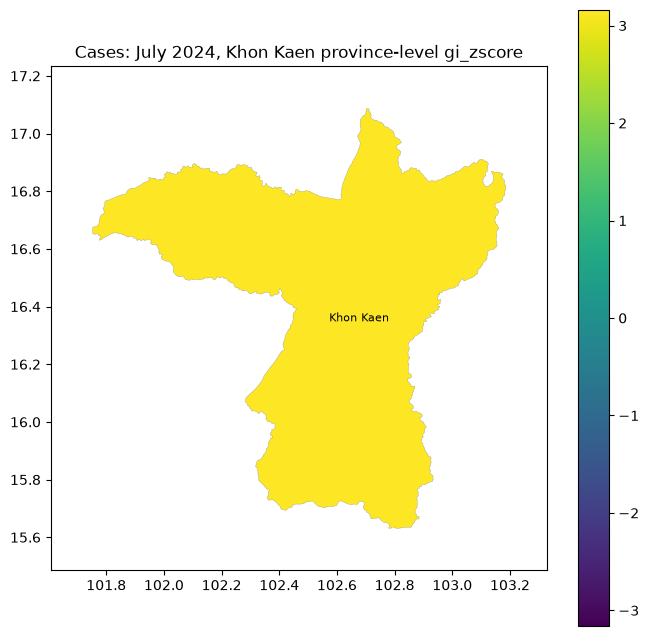

In [42]:
july_df = moving_df[moving_df["month"] == "2024-07"]
with warnings.catch_warnings():
    warnings.simplefilter("ignore", UserWarning)
    july_province = province_hotspots(july_df, k=5, permutations=199)
    july_district = district_hotspots(july_df, k=5, permutations=199)
    july_subdistrict = subdistrict_hotspots(july_df, k=5, permutations=199)

print_top(july_province, "province_en", "July 2024 (expect Khon Kaen), provinces")
print_top(july_district, "district_en", "July 2024, Khon Kaen districts")
print_top(july_subdistrict, "subdistrict_en", "July 2024, Khon Kaen subdistricts")

plot_hotspots(
    july_province, province="TH40", cmap="viridis", show_labels=True, label_fontsize=8, label_color="black"
).set_title("Cases: July 2024, Khon Kaen province-level gi_zscore")


Text(0.5, 1.0, 'Cases: July 2024, Khon Kaen districts, gi_zscore')

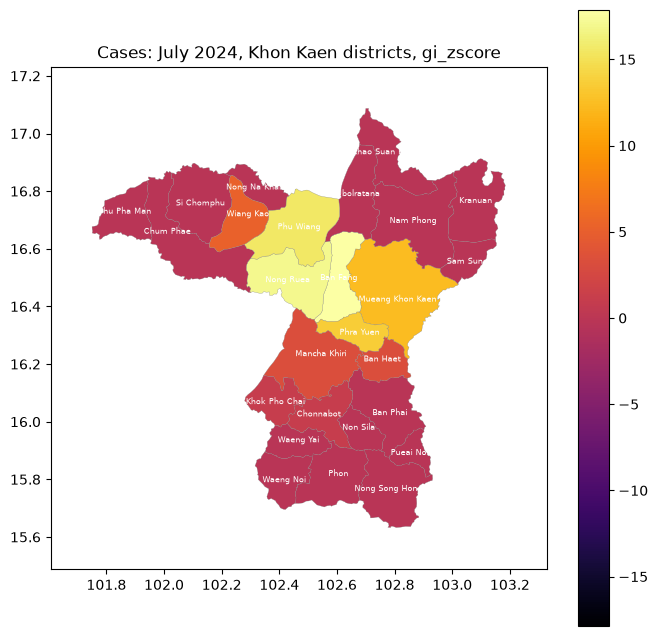

In [43]:
plot_hotspots(
    july_district, province="TH40", cmap="inferno", show_labels=True, label_fontsize=6, label_color="white"
).set_title("Cases: July 2024, Khon Kaen districts, gi_zscore")


Text(0.5, 1.0, 'Cases: July 2024, Khon Kaen subdistrict-level gi_zscore')

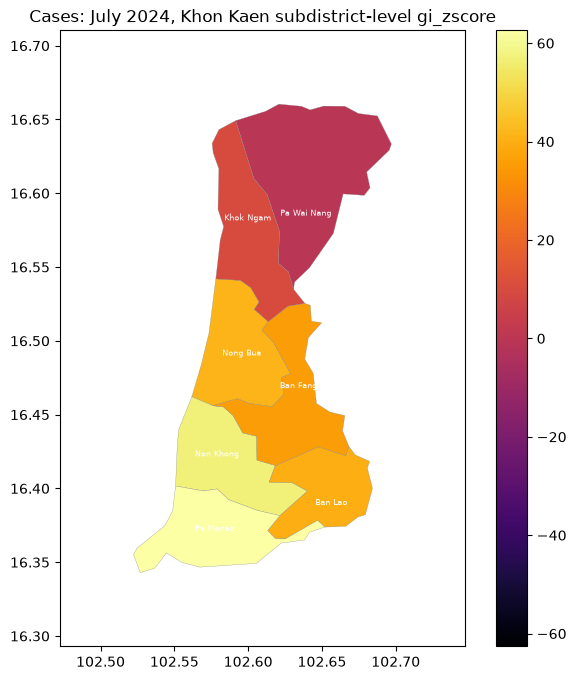

In [44]:
plot_hotspots(
    july_subdistrict, district=top_code(july_district, "district_code"), cmap="inferno",
    show_labels=True, label_fontsize=6, label_color="white",
).set_title("Cases: July 2024, Khon Kaen subdistrict-level gi_zscore")


## 10. EARS temporal anomaly detection

Every hotspot detector above (`getis_ord_hotspots`/`province_hotspots`/`district_hotspots`/
`subdistrict_hotspots`/`spatiotemporal_hotspots`) flags a unit as anomalous relative to its
*spatial* neighbors within one time period. None of them look backward in time -- a unit that's
high but unremarkable next to its neighbors, yet far above its own recent history, won't show up.

`province_ears`/`district_ears`/`subdistrict_ears` are the complementary, purely *temporal* check:
each unit's value is compared only to its own past values (CDC's EARS C1/C2/C3 historical-limits
algorithms), independent of what its neighbors are doing. No `k`/`permutations`/`alpha` -- there's
no spatial weights matrix here.

Each block below gives Chiang Mai a low, steady history relative to its neighbors, then a late
jump that lands squarely inside the range its neighbors occupy *every* period -- so Getis-Ord
Gi* (comparing it to those neighbors, within one period) finds nothing remarkable, while EARS
(comparing that period to Chiang Mai's own priors) flags it immediately. Kept as three blocks,
like the spatiotemporal timeframe detail above, since each grain needs its own period spacing
and enough history for `baseline_window` (+2 for c2's guard band) periods -- day needs only ~2
weeks of history, month needs the better part of a year.

In [45]:
def make_dense_temporal_outbreak(period_starts, spike_final_n, spike_background_range, background_range):
    """Dense per-province case counts at every period (avoids the +-inf/sparse-data EARS
    caveat), where Chiang Mai's own history sits well below its neighbors' steady volume
    until the final period, when it jumps to spike_final_n -- still inside its neighbors'
    normal range (spatially unremarkable) but far above its own baseline (temporally extreme)."""
    with open("../data/thailand_admin_centroids.json") as f:
        ears_provinces = pd.DataFrame(json.load(f)["provinces"])
    background_codes = ["TH11", "TH12", "TH13", "TH14", "TH15", "TH16", "TH17", "TH18", "TH19"]
    spike_code = ears_provinces.loc[ears_provinces["province_en"] == "Chiang Mai", "province_code"].iloc[0]
    chosen = ears_provinces[ears_provinces["province_code"].isin([*background_codes, spike_code])]

    frames = []
    for i, period_start in enumerate(period_starts):
        for _, p in chosen.iterrows():
            if p["province_code"] == spike_code:
                n = spike_final_n if i == len(period_starts) - 1 else int(rng.integers(*spike_background_range))
            else:
                n = int(rng.integers(*background_range))
            frames.append(
                pd.DataFrame(
                    {
                        "lon": rng.normal(p["lon"], 0.05, size=n),
                        "lat": rng.normal(p["lat"], 0.05, size=n),
                        "reported_at": period_start,
                    }
                )
            )
    return pd.concat(frames, ignore_index=True)

### Day

EARS reacts fast at day grain (`baseline_window` in days) -- useful for catching a single-day
spike as soon as it happens.

In [46]:
day_starts = pd.to_datetime("2024-01-01") + pd.to_timedelta(np.arange(12), unit="D")
day_outbreak_df = make_dense_temporal_outbreak(
    day_starts, spike_final_n=15, spike_background_range=(1, 4), background_range=(5, 10)
)

with warnings.catch_warnings():
    warnings.simplefilter("ignore", UserWarning)  # libpysal disconnected-components notice
    spatial_last_day = province_hotspots(day_outbreak_df[day_outbreak_df["reported_at"] == day_starts[-1]], k=5, permutations=499)
cm_spatial_day = spatial_last_day[spatial_last_day["province_en"] == "Chiang Mai"].iloc[0]
day_rank = int((spatial_last_day["gi_zscore"] > cm_spatial_day["gi_zscore"]).sum()) + 1
print(
    f"Day {day_starts[-1].date()}: Chiang Mai count={cm_spatial_day['count']:.0f}, "
    f"gi_zscore={cm_spatial_day['gi_zscore']:.2f} (rank {day_rank}/{len(spatial_last_day)} -- unremarkable spatially)"
)

Day 2024-01-12: Chiang Mai count=15, gi_zscore=1.40 (rank 13/77 -- unremarkable spatially)


In [47]:
day_ears = province_ears(day_outbreak_df, time_col="reported_at", timeframe="day", baseline_window=7)
cm_day_ears = day_ears[day_ears["province_en"] == "Chiang Mai"].sort_values("time_bin")
cm_day_ears[["time_bin", "count", "c1", "c2", "c2_alert"]]

,time_bin,count,c1,c2,c2_alert
456,2024-01-01,3.0,NaN,NaN,False
457,2024-01-02,2.0,NaN,NaN,False
458,2024-01-03,1.0,NaN,NaN,False
459,2024-01-04,1.0,NaN,NaN,False
460,2024-01-05,1.0,NaN,NaN,False
461,2024-01-06,2.0,NaN,NaN,False
462,2024-01-07,1.0,NaN,NaN,False
463,2024-01-08,2.0,0.544705,NaN,False
464,2024-01-09,1.0,-0.801784,NaN,False
465,2024-01-10,1.0,-0.585540,-0.726273,False


<Axes: title={'center': 'Province-level c2'}>

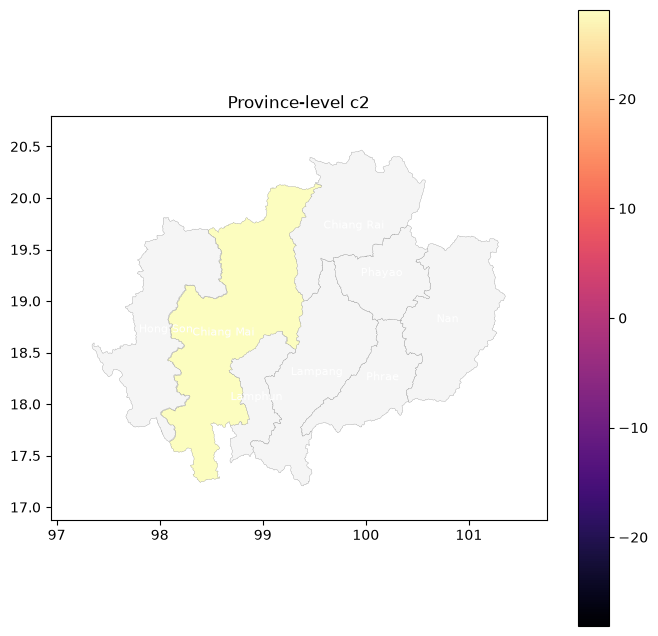

In [48]:
plot_hotspots(
    day_ears[day_ears["time_bin"] == cm_day_ears["time_bin"].iloc[-1]],
    value_col="c2",
    health_zone=1,
    cmap="magma",
    show_labels=True,
    label_fontsize=8,
    label_color="white",
)

### Week

Same idea, but also drilling into district-level EARS within the flagged province --
`district_ears` shares `province_ears`'s zero-fill panel logic.

In [49]:
week_starts = pd.to_datetime("2024-01-01") + pd.to_timedelta(np.arange(10) * 7, unit="D")
week_outbreak_df = make_dense_temporal_outbreak(
    week_starts, spike_final_n=20, spike_background_range=(3, 6), background_range=(15, 25)
)

with warnings.catch_warnings():
    warnings.simplefilter("ignore", UserWarning)
    spatial_last_week = province_hotspots(week_outbreak_df[week_outbreak_df["reported_at"] == week_starts[-1]], k=5, permutations=499)
cm_spatial_week = spatial_last_week[spatial_last_week["province_en"] == "Chiang Mai"].iloc[0]
week_rank = int((spatial_last_week["gi_zscore"] > cm_spatial_week["gi_zscore"]).sum()) + 1
print(
    f"Week {week_starts[-1].date()}: Chiang Mai count={cm_spatial_week['count']:.0f}, "
    f"gi_zscore={cm_spatial_week['gi_zscore']:.2f} (rank {week_rank}/{len(spatial_last_week)} -- unremarkable spatially)"
)

Week 2024-03-04: Chiang Mai count=20, gi_zscore=0.26 (rank 21/77 -- unremarkable spatially)


In [50]:
week_province_ears = province_ears(week_outbreak_df, time_col="reported_at", timeframe="week", baseline_window=7)
cm_week_ears = week_province_ears[week_province_ears["province_en"] == "Chiang Mai"].sort_values("time_bin")
cm_week_ears[["time_bin", "count", "c1", "c2", "c2_alert"]]

,time_bin,count,c1,c2,c2_alert
380,2024-01-01/2024-01-07,3.0,NaN,NaN,False
381,2024-01-08/2024-01-14,4.0,NaN,NaN,False
382,2024-01-15/2024-01-21,5.0,NaN,NaN,False
383,2024-01-22/2024-01-28,3.0,NaN,NaN,False
384,2024-01-29/2024-02-04,5.0,NaN,NaN,False
385,2024-02-05/2024-02-11,4.0,NaN,NaN,False
386,2024-02-12/2024-02-18,5.0,NaN,NaN,False
387,2024-02-19/2024-02-25,5.0,0.952661,NaN,False
388,2024-02-26/2024-03-03,5.0,0.726273,NaN,False
389,2024-03-04/2024-03-10,20.0,19.609372,17.624229,True


Not plotted at district grain: even a single sparse, near-zero-variance district can be
`+-inf`, which would collapse `plot_hotspots`'s color scale to a single useless shade (see
Mae Rim below) -- the printed table is the trustworthy view here, not a choropleth.

In [51]:
week_district_ears = district_ears(week_outbreak_df, time_col="reported_at", timeframe="week", baseline_window=7)
last_week_label = cm_week_ears["time_bin"].iloc[-1]
spike_province_code = week_province_ears.loc[week_province_ears["province_en"] == "Chiang Mai", "province_code"].iloc[0]
cm_districts = week_district_ears[
    (week_district_ears["time_bin"] == last_week_label) & (week_district_ears["province_code"] == spike_province_code)
].sort_values("c2", ascending=False)
cm_districts[["district_en", "count", "c2", "c2_alert"]].head(5)

,district_en,count,c2,c2_alert
5269,Samoeng,12.0,17.906503,True
5409,Mae Wang,7.0,7.559289,True
5339,Hang Dong,1.0,1.069045,False
5199,Mueang Chiang Mai,0.0,NaN,False
5209,Chom Thong,0.0,NaN,False


### Month

EARS is least reactive here (needs the better part of a year of monthly history for
`baseline_window=5` + the 2-period guard band), but smooths out day-to-day/week-to-week noise.

In [52]:
month_starts = pd.date_range("2023-01-01", periods=8, freq="MS")
month_outbreak_df = make_dense_temporal_outbreak(
    month_starts, spike_final_n=80, spike_background_range=(10, 15), background_range=(60, 90)
)

with warnings.catch_warnings():
    warnings.simplefilter("ignore", UserWarning)
    spatial_last_month = province_hotspots(month_outbreak_df[month_outbreak_df["reported_at"] == month_starts[-1]], k=5, permutations=499)
cm_spatial_month = spatial_last_month[spatial_last_month["province_en"] == "Chiang Mai"].iloc[0]
month_rank = int((spatial_last_month["gi_zscore"] > cm_spatial_month["gi_zscore"]).sum()) + 1
print(
    f"Month {month_starts[-1].strftime('%Y-%m')}: Chiang Mai count={cm_spatial_month['count']:.0f}, "
    f"gi_zscore={cm_spatial_month['gi_zscore']:.2f} (rank {month_rank}/{len(spatial_last_month)} -- unremarkable spatially)"
)

Month 2023-08: Chiang Mai count=80, gi_zscore=0.42 (rank 17/77 -- unremarkable spatially)


In [53]:
month_ears = province_ears(month_outbreak_df, time_col="reported_at", timeframe="month", baseline_window=5)
cm_month_ears = month_ears[month_ears["province_en"] == "Chiang Mai"].sort_values("time_bin")
cm_month_ears[["time_bin", "count", "c1", "c2", "c2_alert"]]

,time_bin,count,c1,c2,c2_alert
304,2023-01,13.0,NaN,NaN,False
305,2023-02,12.0,NaN,NaN,False
306,2023-03,10.0,NaN,NaN,False
307,2023-04,10.0,NaN,NaN,False
308,2023-05,14.0,NaN,NaN,False
309,2023-06,13.0,0.670820,NaN,False
310,2023-07,10.0,-1.006231,NaN,False
311,2023-08,80.0,35.191057,38.124959,True


<Axes: title={'center': 'Province-level c2'}>

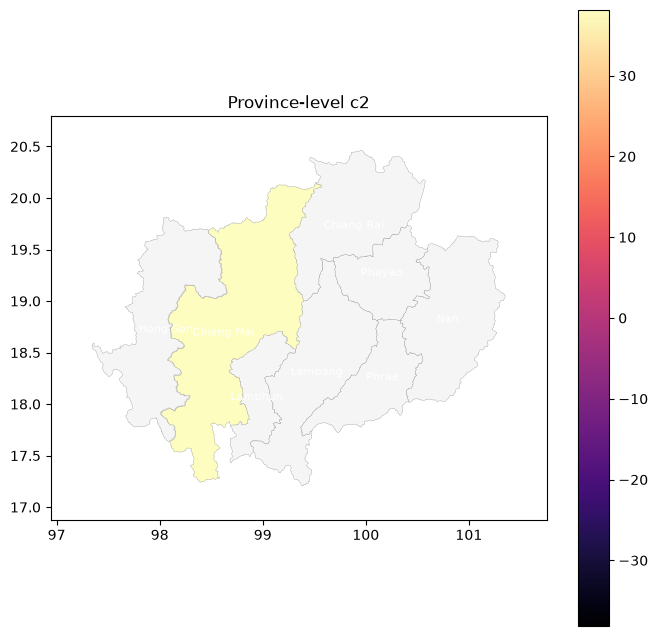

In [54]:
plot_hotspots(
    month_ears[month_ears["time_bin"] == cm_month_ears["time_bin"].iloc[-1]],
    value_col="c2",
    health_zone=1,
    cmap="magma",
    show_labels=True,
    label_fontsize=8,
    label_color="white",
)

`subdistrict_ears` is intentionally not demoed here: at subdistrict grain most units sit at
0-1 cases per period, so the baseline is usually zero-variance and `c2`/`c3` collapse into
`+-inf` noise rather than a meaningful signal -- see the sparse-data caveat in the README and
`spatialdetection.temporal`'s module docstring.